# Efficiency Frontier — results explorer

Live companion to `PLAN.md`: **Run All to refresh as stage outputs land.** Every stage cell
guards on its output file existing, so the notebook runs cleanly at any point of the campaign
and simply reports which stages are still pending.

**Conventions (house rules that bite here):**
- Frontier columns are **matched-efficiency** working points (τ at the k-th true amplitude, the XII convention) — never judge the normalized ±½ or fitted families at fixed τ=0.35 (amplitude-convention artifact; their fixed-τ ~0.5 is expected).
- Every operating degree carries its **d & d+4 twin**; a pair disagreeing by >1 % eff is UNSTABLE (open markers below), per the BE-05 ripple rule.
- `far = n_false_active / n_active`; targets: moderate **eff ≥ 0.995 @ far ≤ 0.01**, heavy composed Pareto vs **(0.985, 0.018)**.

Data provenance: `outputs/*.csv` (committed) + `outputs/cache/01_amps_*.npz` (local amplitude caches, regenerate with `01_degree_response_frontier.py`).

In [1]:
%matplotlib inline
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Efficiency_Frontier")
OUT, CACHE = HERE / "outputs", HERE / "outputs" / "cache"

# house palette — color follows the FAMILY, fixed everywhere (never re-cycled)
FAM_COL = {
    "classical_invA":       "#52514e",
    "1bqf_cos":             "#e34948",
    "comb_prod":            "#4a3aa7",
    "band_inverse":         "#2a78d6",
    "sharp_comb":           "#8a63d2",
    "normalized_half_comb": "#eb6834",
    "fitted_ridge":         "#1baf7a",
    "fitted_binned":        "#0d7a52",
    "fitted_xval":          "#7fc7a8",
}
FAM_LAB = {
    "classical_invA": "classical 1/λ", "1bqf_cos": "1BQF cos",
    "comb_prod": "comb hw0.18", "band_inverse": "band inverse",
    "sharp_comb": "sharp hw0.06", "normalized_half_comb": "normalized ±½",
    "fitted_ridge": "fitted (Cheb.)", "fitted_binned": "fitted (binned)",
    "fitted_xval": "fitted (x-val)",
}

STAGES = {
    "0 inventory":  ["00_inventory.csv", "00_gap_list.csv"],
    "1 degree×response": ["01_frontier_clean_moderate.csv"],
    "2 set-outs":   ["02_setout_frontier.csv"],
    "3 composition": ["03_composed_frontier.csv", "04_loss_budget.csv"],
    "4 confirmation": ["05_confirmation.csv"],
}

def load(name):
    p = OUT / name
    return pd.read_csv(p) if p.exists() else None

print(f"status @ {time.strftime('%Y-%m-%d %H:%M')}")
for stage, files in STAGES.items():
    for f in files:
        p = OUT / f
        if p.exists():
            df_ = pd.read_csv(p)
            print(f"  [x] {stage:18s} {f:32s} {len(df_):>6} rows   "
                  f"{time.strftime('%m-%d %H:%M', time.localtime(p.stat().st_mtime))}")
        else:
            print(f"  [ ] {stage:18s} {f:32s} — not yet produced")
caches = sorted(CACHE.glob("01_amps_*.npz"))
print(f"  amplitude caches: {len(caches)} "
      f"({', '.join(c.stem.replace('01_amps_', '') for c in caches)})")

status @ 2026-08-24 15:25
  [x] 0 inventory        00_inventory.csv                  38011 rows   08-24 14:54
  [x] 0 inventory        00_gap_list.csv                      76 rows   08-24 14:54
  [x] 1 degree×response  01_frontier_clean_moderate.csv      304 rows   08-24 15:17
  [ ] 2 set-outs         02_setout_frontier.csv           — not yet produced
  [ ] 3 composition      03_composed_frontier.csv         — not yet produced
  [ ] 3 composition      04_loss_budget.csv               — not yet produced
  [ ] 4 confirmation     05_confirmation.csv              — not yet produced
  amplitude caches: 6 (clean_rep0, clean_rep1, clean_rep2, moderate_rep0, moderate_rep1, moderate_rep2)


## Stage 0 — inventory coverage & the frozen gap list

In [2]:
inv, gaps = load("00_inventory.csv"), load("00_gap_list.csv")
if inv is None:
    print("Stage 0 not yet produced")
else:
    inv["regime_c"] = inv["regime"].where(~inv["regime"].str.startswith("other("),
                                          "other (robustness axes)")
    display(inv.pivot_table(index="response_family", columns="regime_c",
                            values="eff", aggfunc="count", fill_value=0))
    print("gap list:", dict(gaps["status"].value_counts()))
    display(gaps[gaps.status != "missing"].head(20))

regime_c,clean,clean+drop1%,heavy,moderate,other (robustness axes)
response_family,,,,,
1bqf_cos,3312,408,63,448,6768
classical_invA,4825,2190,146,2565,12760
comb_prod,1120,554,67,448,1864
fitted_cheb,0,0,81,0,0
fitted_ridge,0,0,334,0,0
fitted_ridge_xval,0,0,30,0,0
normalized_half_comb,24,0,0,0,0


gap list: {'missing': np.int64(62), 'covered': np.int64(11), 'partial': np.int64(3)}


,regime,T,response_family,degree,reps_have,reps_needed,status,notes
0,clean,200,comb_prod,8,3,3,covered,S1 production comb
1,clean,200,comb_prod,12,3,3,covered,S1 production comb
2,clean,200,comb_prod,16,3,3,covered,S1 production comb
3,clean,200,comb_prod,20,3,3,covered,S1 production comb
4,clean,200,comb_prod,24,3,3,covered,S1 production comb
5,clean,200,comb_prod,28,3,3,covered,S1 production comb
6,clean,200,comb_prod,32,3,3,covered,S1 production comb
7,clean,200,comb_prod,40,10,3,covered,S1 production comb
25,clean,200,normalized_half_comb,12,1,3,partial,S1 normalized +-1/2 comb
26,clean,200,normalized_half_comb,20,1,3,partial,S1 normalized +-1/2 comb


## Stage 1 — degree scan per response family

Left: efficiency at far ≤ 1 % (the attainable frontier). Right: far at matched eff 0.995
(≈0.5 everywhere on moderate = the fragment-floor flood). Error bars = rep spread; **open
markers = the d/d+4 stability stamp FAILED** (>1 % eff disagreement with the twin).

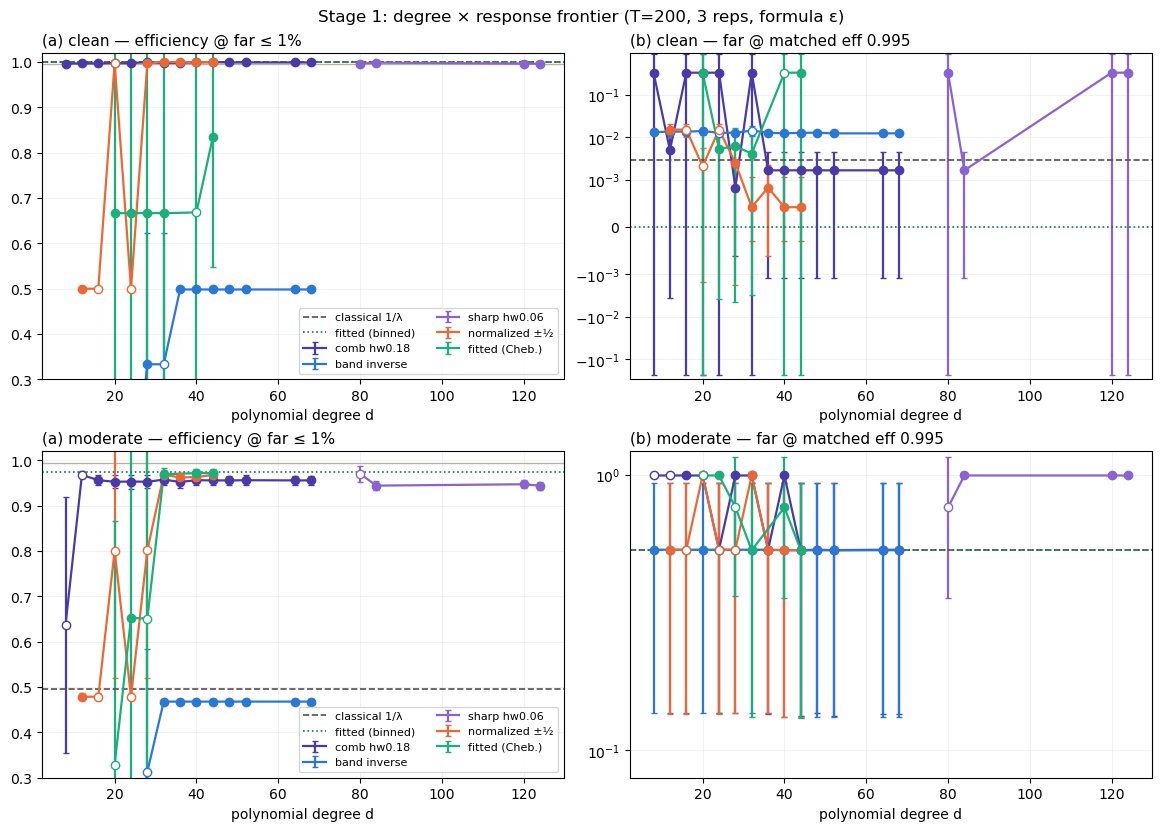

In [3]:
f1 = load("01_frontier_clean_moderate.csv")
if f1 is None:
    print("Stage 1 not yet produced")
else:
    DEG_FAMS = ["comb_prod", "band_inverse", "sharp_comb",
                "normalized_half_comb", "fitted_ridge"]
    regimes = [r for r in ["clean", "moderate", "heavy"] if (f1.regime == r).any()]
    fig, axes = plt.subplots(len(regimes), 2, figsize=(11.5, 4.1 * len(regimes)),
                             constrained_layout=True)
    axes = np.atleast_2d(axes)
    for i, rg in enumerate(regimes):
        sub = f1[f1.regime == rg]
        m = (sub.groupby(["family", "degree"], dropna=False)
                [["eff_f010", "far_e995"]].agg(["mean", "std"]).reset_index())
        m.columns = ["family", "degree", "eff_mean", "eff_std",
                     "far_mean", "far_std"]
        for j, (col, lab) in enumerate([("eff", "efficiency @ far ≤ 1%"),
                                        ("far", "far @ matched eff 0.995")]):
            ax = axes[i, j]
            for fam in DEG_FAMS:
                mf = m[m["family"] == fam].dropna(subset=["degree"]).sort_values("degree")
                if not len(mf):
                    continue
                ax.errorbar(mf["degree"], mf[f"{col}_mean"], yerr=mf[f"{col}_std"],
                            color=FAM_COL[fam], lw=1.6, ms=0, capsize=2, zorder=2,
                            label=FAM_LAB[fam])
                # stability stamp vs the d+4 twin (judged on efficiency)
                eff_by_d = dict(zip(mf["degree"], mf["eff_mean"]))
                for d, v in zip(mf["degree"], mf[f"{col}_mean"]):
                    tw = eff_by_d.get(d + 4)
                    unstable = tw is not None and abs(eff_by_d[d] - tw) > 0.01
                    ax.plot([d], [v], "o", ms=6, color=FAM_COL[fam], zorder=3,
                            mfc="white" if unstable else FAM_COL[fam])
            for fam, ls in [("classical_invA", "--"), ("fitted_binned", ":")]:
                ref = sub[sub.family == fam][f"{'eff_f010' if col == 'eff' else 'far_e995'}"].mean()
                if np.isfinite(ref):
                    ax.axhline(ref, color=FAM_COL[fam], ls=ls, lw=1.2,
                               label=FAM_LAB[fam])
            if col == "eff":
                ax.axhline(0.995, color="#b7b3a8", lw=1, zorder=0)
                ax.set_ylim(0.3, 1.02)
            else:
                ax.set_yscale("symlog", linthresh=1e-3)
            ax.set_title(f"({'ab'[j]}) {rg} — {lab}", loc="left", fontsize=11)
            ax.set_xlabel("polynomial degree d")
            ax.grid(alpha=0.25, lw=0.5)
        axes[i, 0].legend(fontsize=8, ncol=2, loc="lower right")
    fig.suptitle("Stage 1: degree × response frontier (T=200, 3 reps, formula ε)",
                 fontsize=12)
    plt.show()

## Stage 1 — full ROC curves (the frontier is the object)

Built from the amplitude caches; grey crosshair = the success target (eff 0.995, far 0.01).

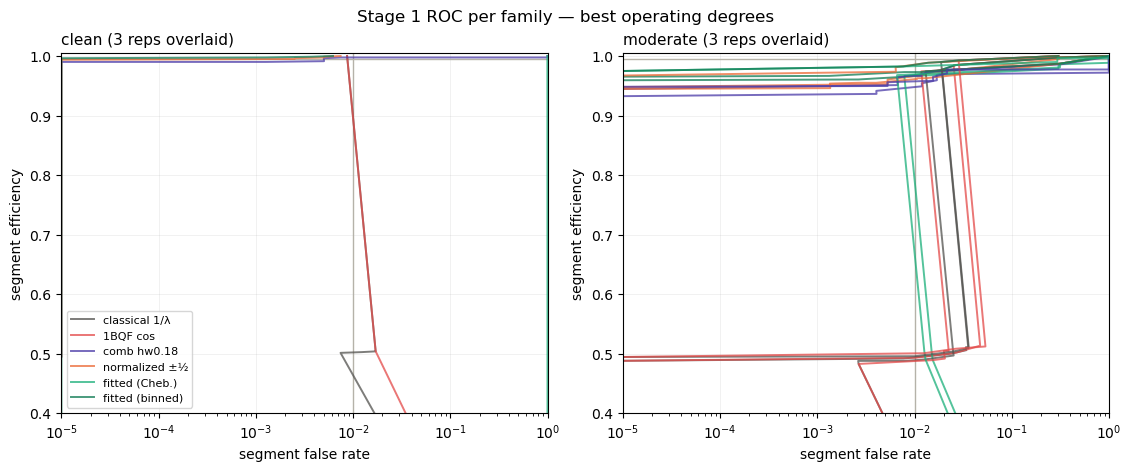

In [4]:
def roc(x, truth, npts=1200):
    x = np.abs(np.asarray(x, float)); truth = np.asarray(truth, bool)
    n_true = truth.sum()
    taus = np.quantile(np.unique(x[truth]), np.linspace(0, 1, min(npts, n_true)))[::-1]
    xs, xt = np.sort(x), np.sort(x[truth])
    nact = len(x) - np.searchsorted(xs, taus, side="left")
    ntru = n_true - np.searchsorted(xt, taus, side="left")
    far = np.where(nact > 0, (nact - ntru) / np.maximum(nact, 1), np.nan)
    return ntru / n_true, far

SHOW = ["classical_invA_dnan", "1bqf_cos_d1", "comb_prod_d40",
        "normalized_half_comb_d44", "fitted_ridge_d40", "fitted_binned_dnan"]
caches = {p.stem.replace("01_amps_", ""): p for p in sorted(CACHE.glob("01_amps_*.npz"))}
if not caches:
    print("no amplitude caches — run 01_degree_response_frontier.py")
else:
    regs = sorted({k.rsplit("_rep", 1)[0] for k in caches})
    fig, axes = plt.subplots(1, len(regs), figsize=(5.6 * len(regs), 4.6),
                             constrained_layout=True, squeeze=False)
    for ax, rg in zip(axes[0], regs):
        for rep in (0, 1, 2):
            key = f"{rg}_rep{rep}"
            if key not in caches:
                continue
            z = np.load(caches[key])
            truth = z["truth"]
            for name in SHOW:
                if name not in z.files:
                    continue
                fam = name.rsplit("_d", 1)[0]
                e, f = roc(z[name], truth)
                ax.plot(np.clip(f, 1e-5, None), e, color=FAM_COL[fam], lw=1.4,
                        alpha=0.75, label=FAM_LAB[fam] if rep == 0 else None)
        ax.axvline(0.01, color="#b7b3a8", lw=1, zorder=0)
        ax.axhline(0.995, color="#b7b3a8", lw=1, zorder=0)
        ax.set_xscale("log"); ax.set_xlim(1e-5, 1); ax.set_ylim(0.4, 1.005)
        ax.set_xlabel("segment false rate"); ax.set_ylabel("segment efficiency")
        ax.set_title(f"{rg} (3 reps overlaid)", loc="left", fontsize=11)
        ax.grid(alpha=0.25, lw=0.5)
    axes[0, 0].legend(fontsize=8, loc="lower left")
    fig.suptitle("Stage 1 ROC per family — best operating degrees", fontsize=12)
    plt.show()

## Stage 1 — amplitude spectra (where the floor lives)

True vs false amplitude pile-up for a chosen config; change `PICK` freely. The moderate
true population's low-amplitude tail (fragments/twins) is the ~3 % that no response recovers.

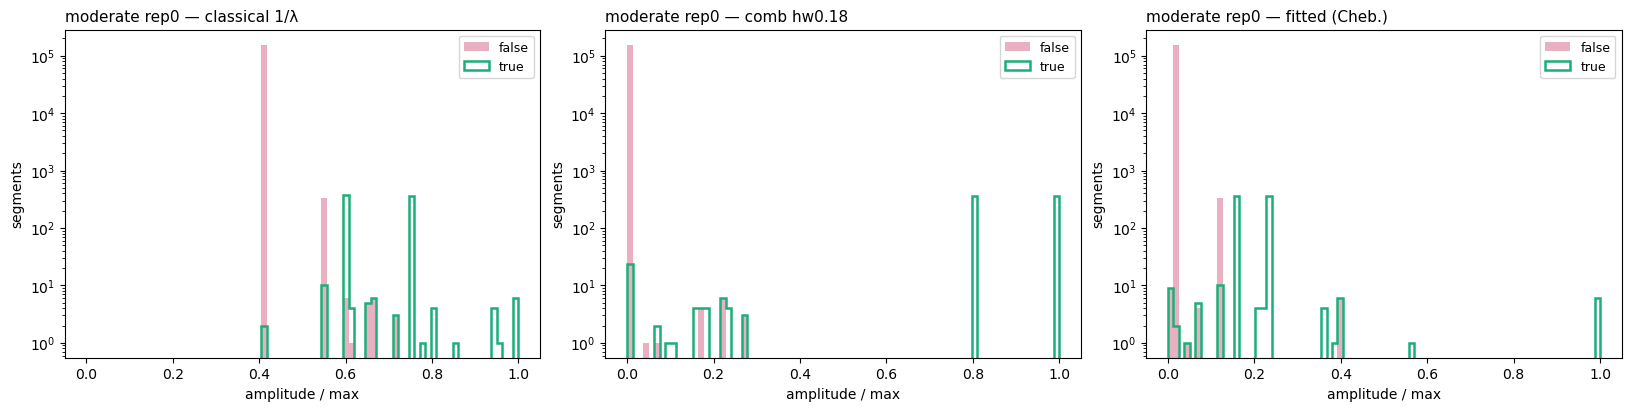

In [5]:
PICK = [("moderate", 0, "classical_invA_dnan"),
        ("moderate", 0, "comb_prod_d40"),
        ("moderate", 0, "fitted_ridge_d40")]
avail = [(rg, rep, key) for (rg, rep, key) in PICK
         if (CACHE / f"01_amps_{rg}_rep{rep}.npz").exists()]
if not avail:
    print("no amplitude caches — run 01_degree_response_frontier.py")
else:
    fig, axes = plt.subplots(1, len(avail), figsize=(5.4 * len(avail), 4.0),
                             constrained_layout=True, squeeze=False)
    for ax, (rg, rep, key) in zip(axes[0], avail):
        z = np.load(CACHE / f"01_amps_{rg}_rep{rep}.npz")
        if key not in z.files:
            ax.set_title(f"{key} not in cache"); continue
        x = np.abs(z[key]).astype(float); truth = z["truth"].astype(bool)
        x = x / max(x.max(), 1e-30)
        bins = np.linspace(0, 1, 80)
        ax.hist(x[~truth], bins=bins, color="#e9b0c2", label="false", log=True)
        ax.hist(x[truth], bins=bins, histtype="step", lw=1.8, color="#1baf7a",
                label="true", log=True)
        fam = key.rsplit("_d", 1)[0]
        ax.set_title(f"{rg} rep{rep} — {FAM_LAB.get(fam, fam)}", loc="left", fontsize=11)
        ax.set_xlabel("amplitude / max"); ax.set_ylabel("segments")
        ax.legend(fontsize=9)
    plt.show()

## Stage 2 — Hamiltonian set-outs (auto-loads when produced)

In [6]:
f2 = load("02_setout_frontier.csv")
if f2 is None:
    print("Stage 2 not yet produced — expected schema: Stage-1 columns + set-out knobs")
elif "eff_f010" in f2.columns:
    keys = [c for c in ["setout", "occ_alpha", "eps_scale", "gamma", "kernel",
                        "normalization", "fork_beta"] if c in f2.columns]
    best = (f2.groupby(["regime", "family", "degree"] + keys, dropna=False)
              [["eff_f010", "far_e995"]].mean().reset_index()
              .sort_values("eff_f010", ascending=False))
    display(best.head(25).round(4))
else:
    display(f2.head(20))

Stage 2 not yet produced — expected schema: Stage-1 columns + set-out knobs


## Stage 3 — heavy composition + the L1–L4 loss budget (auto-loads when produced)

In [7]:
f3, f4 = load("03_composed_frontier.csv"), load("04_loss_budget.csv")
if f3 is None:
    print("Stage 3 composed frontier not yet produced — target to dominate: (eff 0.985, far 0.018)")
else:
    display(f3.head(20))
if f4 is None:
    print("Stage 3 loss budget not yet produced — the central deliverable: stacked L1–L4 per config")
elif {"L1", "L2", "L3", "L4"} <= set(f4.columns):
    cfg = f4.groupby("config")[["L1", "L2", "L3", "L4"]].mean()
    ax = cfg.plot.barh(stacked=True, figsize=(8, 0.5 * len(cfg) + 1.5),
                       color=["#52514e", "#4a3aa7", "#eb6834", "#e34948"])
    ax.set_xlabel("efficiency loss (fraction of true segments)")
    ax.set_title("L1 twins · L2 ripple · L3 threshold · L4 slot contest", loc="left")
    plt.show()
else:
    display(f4.head(20))

Stage 3 composed frontier not yet produced — target to dominate: (eff 0.985, far 0.018)
Stage 3 loss budget not yet produced — the central deliverable: stacked L1–L4 per config


## Stage 4 — T=400 confirmation (auto-loads when produced)

In [8]:
f5 = load("05_confirmation.csv")
display(f5.head(20)) if f5 is not None else print("Stage 4 not yet produced")

Stage 4 not yet produced
